
[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\kushs\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2481.55it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


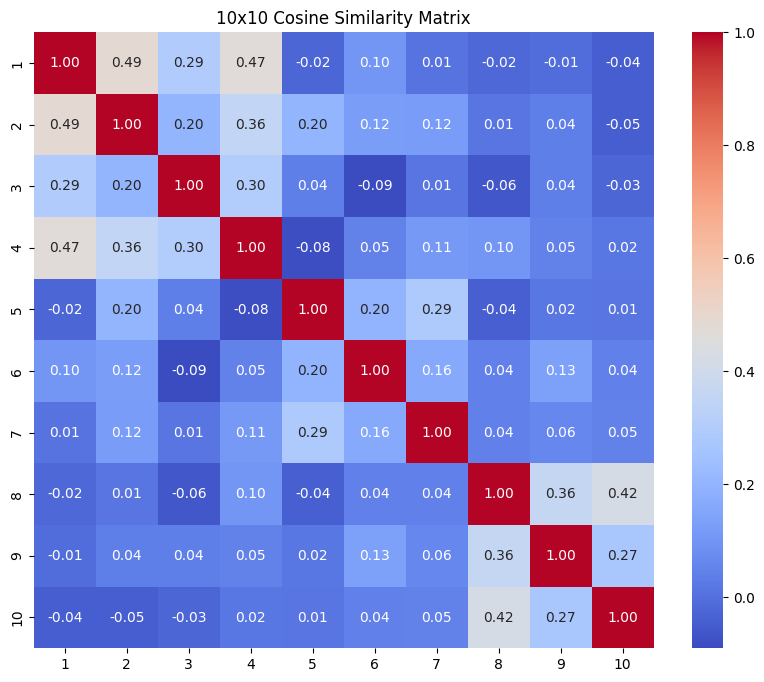

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The bowler delivered a perfect yorker to take the wicket.
Similarity Score: 0.6851

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679



In [9]:
%pip install -q sentence-transformers seaborn matplotlib scikit-learn
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match.",
    "The bowler delivered a perfect yorker to take the wicket.",
    "The team celebrated their victory after a thrilling chase.",
    "Fielding plays a crucial role in winning close matches.",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking requires precise measurements and timing.",
    "Spices can completely change the flavor of a dish.",

    # Cybersecurity (3)
    "Strong passwords are essential for protecting online accounts.",
    "Phishing attacks trick users into revealing sensitive information.",
    "Firewalls help prevent unauthorized access to networks."
]
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("10x10 Cosine Similarity Matrix")
plt.show()
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(scores)[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {scores[idx]:.4f}\n")
